In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

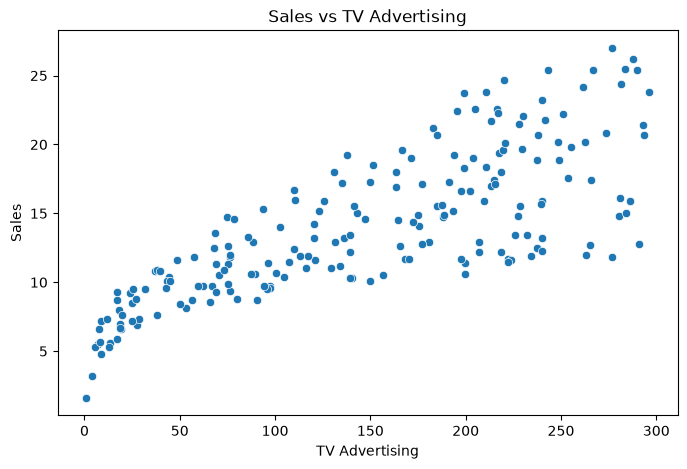

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="TV", y="Sales")
plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.show()

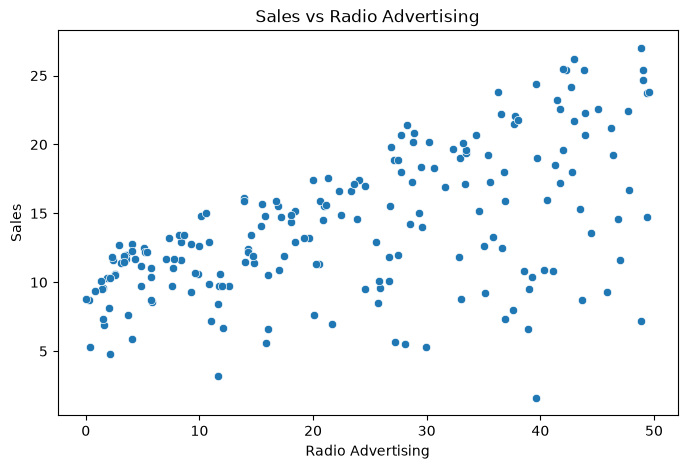

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Radio", y="Sales")
plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.show()

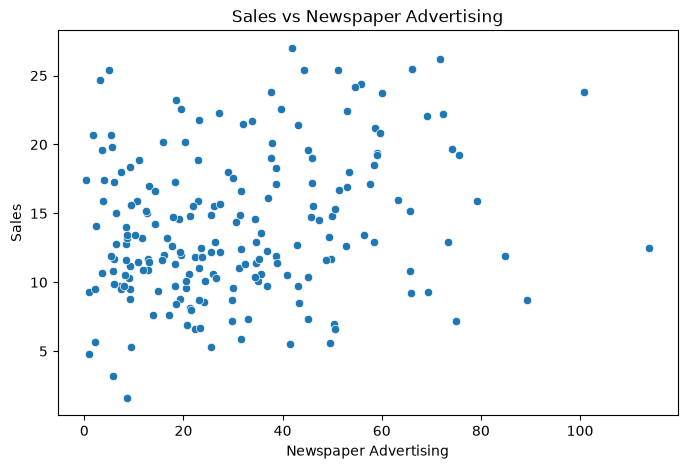

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Newspaper", y="Sales")
plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.show()

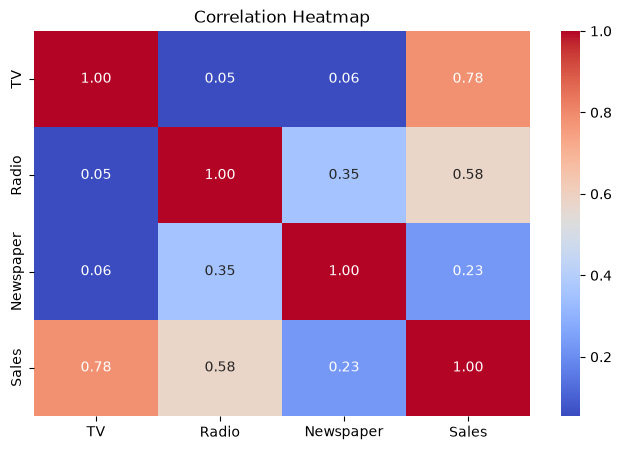

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [11]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912


In [13]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [14]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 0.6203249999999988
RMSE: 0.7687170968568338
R²  : 0.9812782416450916


In [15]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R²": [r2_lr, r2_rf]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620325,0.768717,0.981278


In [16]:
if r2_rf > r2_lr:
    best_model = model_rf
    best_predictions = y_pred_rf
    best_model_name = "Random Forest"
else:
    best_model = model_lr
    best_predictions = y_pred_lr
    best_model_name = "Linear Regression"

print("Best Model:", best_model_name)

Best Model: Random Forest


In [17]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": best_predictions
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.698
1,22.4,21.804
2,21.4,20.619
3,7.3,6.793
4,24.7,22.927
5,12.6,13.379
6,22.3,22.376
7,8.4,9.688
8,11.5,11.826
9,14.9,15.540


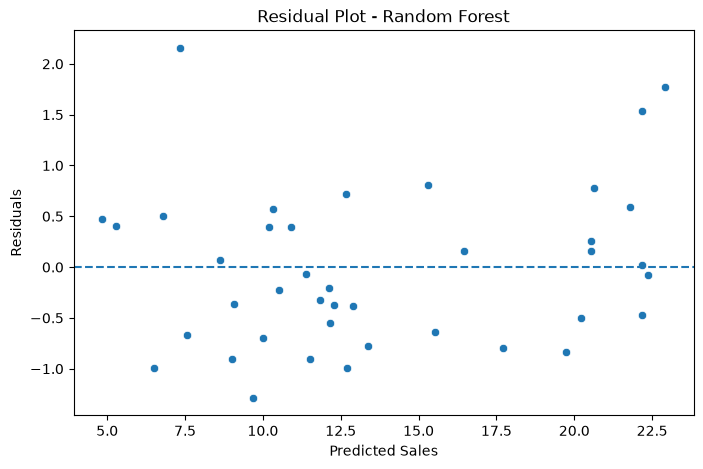

In [18]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_predictions, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624810
1,Radio,0.362214
2,Newspaper,0.012976


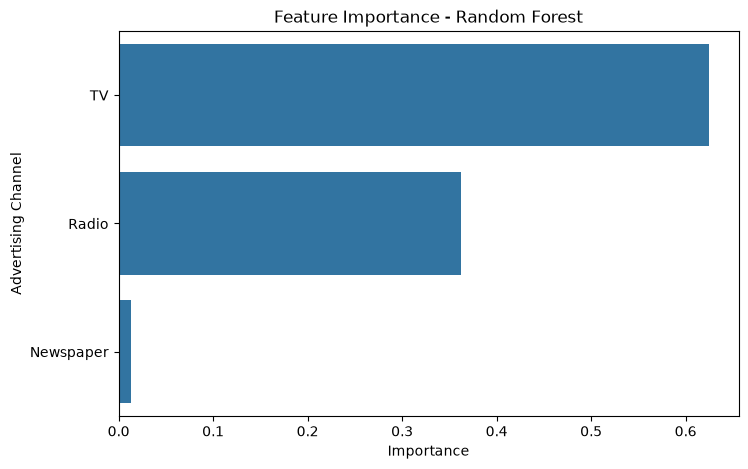

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")
plt.show()

In [21]:
most_important = feature_importance.iloc[0]["Feature"]

print("Most important advertising channel:", most_important)

Most important advertising channel: TV


In [22]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_lr.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [23]:
print("FINAL CONCLUSION")
print("----------------")
print(f"Best performing model: {best_model_name}")
print(f"Linear Regression R²: {r2_lr:.3f}")
print(f"Random Forest R²: {r2_rf:.3f}")
print(f"Most important feature according to Random Forest: {most_important}")

FINAL CONCLUSION
----------------
Best performing model: Random Forest
Linear Regression R²: 0.899
Random Forest R²: 0.981
Most important feature according to Random Forest: TV


## Conclusion

The objective of this project was to predict Sales based on advertising expenditure on TV, Radio, and Newspaper.

The dataset contained 200 records and 4 numerical columns. There were no missing values.

Exploratory Data Analysis showed that TV advertising had the strongest correlation with Sales, followed by Radio, while Newspaper had a weaker relationship.

Two machine learning models were developed:
1. Linear Regression
2. Random Forest Regression

The models were evaluated using MAE, RMSE, and R².

The better-performing model was selected based on the evaluation results. Feature importance was also analyzed to identify which advertising channel contributed most to predicting Sales.

Overall, the analysis demonstrates how advertising expenditure can be used to predict sales using machine learning.